<a href="https://colab.research.google.com/github/KrishKanyal/VIT-MIC-Flight-Price-Analysis/blob/main/flight_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# 1. Load the dataset uploaded to Colab
df = pd.read_csv('flight_pricing_dataset.csv')

# 2. Inspect shape and structure
print("--- DATASET OVERVIEW ---")
print(f"Total rows: {df.shape[0]} | Total columns: {df.shape[1]}\n")

print("--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- DATA TYPES & NULL VALUES ---")
print(df.info())

# 3. Clean missing values & remove duplicate rows
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"\nMissing values found: {missing_count}")
print(f"Duplicate rows found: {duplicate_count}")

df = df.dropna().drop_duplicates()

print(f"\nCleaned dataset ready! Remaining rows: {len(df)}")

--- DATASET OVERVIEW ---
Total rows: 100000 | Total columns: 18

--- FIRST 5 ROWS ---
  Flight_ID          Airline             Source Destination Departure_Date  \
0  FL133547           Indigo          Hyderabad   Ahmedabad     2025-08-02   
1  FL133458    AirAsia India               Pune      Mumbai     2025-06-05   
2  FL173851    Qatar Airways             Sydney         PNQ     2025-02-11   
3  FL101953    AirAsia India  Bangalore Airport         BOM     2025-04-19   
4  FL162887  British Airways             Sydney         Goa     2026-07-05   

  Departure_Time Arrival_Time Duration Total_Stops Distance_km Travel_Class  \
0        8:10 PM        21:50     1.67           0       910.5      Economy   
1          12:10        12:55   0h 45m    non-stop         150      Economy   
2        5:05 PM      7:53 AM    14.80      1 stop     10168.1      Economy   
3          07:05     10:16 AM   3h 11m           1       868.3      Economy   
4       10:40 PM        12:36    13.93    non-stop

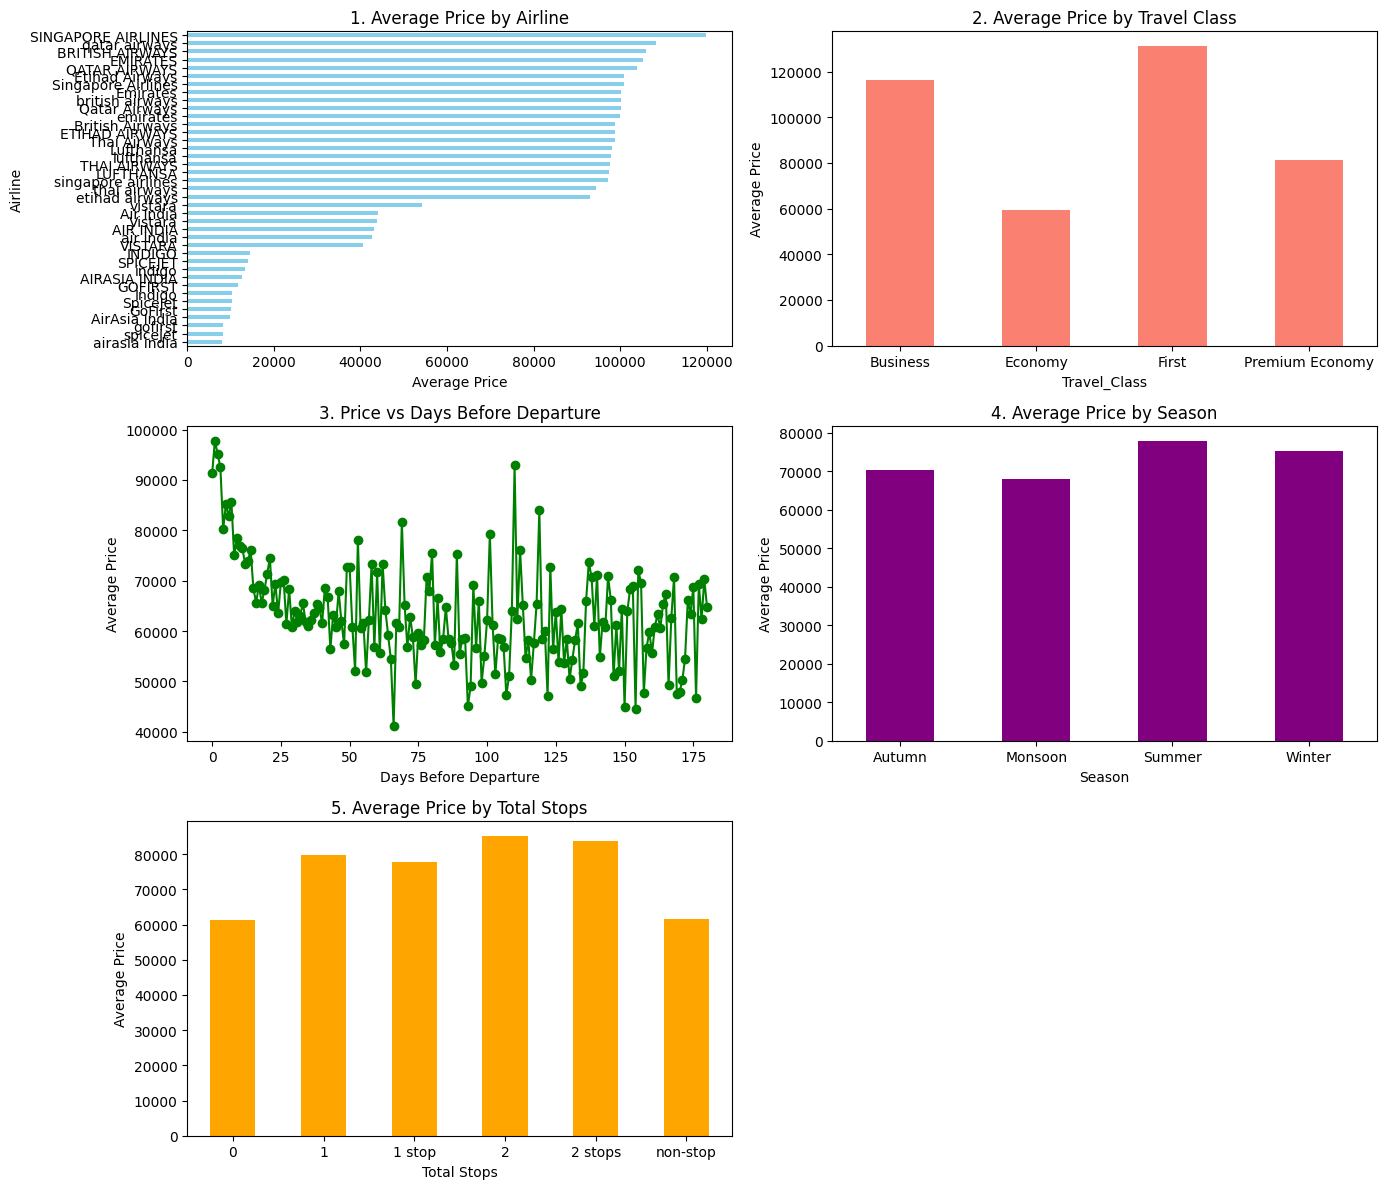

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert numeric columns from text to numbers
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Days_Before_Departure'] = pd.to_numeric(
    df['Days_Before_Departure'], errors='coerce'
)

# Remove any rows where Price couldn't be converted
df = df.dropna(subset=['Price'])

# Set up canvas for 5 charts
plt.figure(figsize=(14, 12))

# Chart 1: Average Price by Airline
plt.subplot(3, 2, 1)
df.groupby('Airline')['Price'].mean().sort_values().plot(
    kind='barh', color='skyblue'
)
plt.title('1. Average Price by Airline')
plt.xlabel('Average Price')

# Chart 2: Price by Travel Class
plt.subplot(3, 2, 2)
df.groupby('Travel_Class')['Price'].mean().plot(kind='bar', color='salmon')
plt.title('2. Average Price by Travel Class')
plt.ylabel('Average Price')
plt.xticks(rotation=0)

# Chart 3: Days Before Departure vs Price
plt.subplot(3, 2, 3)
df.groupby('Days_Before_Departure')['Price'].mean().plot(
    kind='line', marker='o', color='green'
)
plt.title('3. Price vs Days Before Departure')
plt.xlabel('Days Before Departure')
plt.ylabel('Average Price')

# Chart 4: Average Price by Season
plt.subplot(3, 2, 4)
df.groupby('Season')['Price'].mean().plot(kind='bar', color='purple')
plt.title('4. Average Price by Season')
plt.ylabel('Average Price')
plt.xticks(rotation=0)

# Chart 5: Price by Total Stops
plt.subplot(3, 2, 5)
df.groupby('Total_Stops')['Price'].mean().plot(kind='bar', color='orange')
plt.title('5. Average Price by Total Stops')
plt.xlabel('Total Stops')
plt.ylabel('Average Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()